# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
Перед использованием данных с сайта TLC NYC надо удалить дубликаты их и обработать пропуски.

In [23]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-01.parquet')

In [24]:
df.shape

(3475226, 20)

In [25]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [26]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1111181,2,2025-01-13 14:12:03,2025-01-13 14:24:59,1.0,1.99,1.0,N,234,229,1,13.50,0.0,0.5,3.65,0.0,1.0,21.90,2.5,0.0,0.75
3336520,1,2025-01-25 01:39:15,2025-01-25 02:06:22,NaN,10.50,NaN,None,148,243,0,42.83,0.0,0.5,0.00,0.0,1.0,47.58,NaN,NaN,0.75
2449396,2,2025-01-27 09:18:16,2025-01-27 09:32:46,1.0,2.26,1.0,N,140,239,1,15.60,0.0,0.5,4.90,0.0,1.0,24.50,2.5,0.0,0.00


In [27]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

Видим полмиллиона пропусков, причём они подозрительно выглядят, надо понять откуда они появились. Пропуски находятся в следующих признаках: 
1) счётчике пассажиров; 
2) коде тарифа, действовавшего в конце поездки; 
3) индикаторе сохранения записи в памяти автомобиля из-за отсутствия связи с сервером;
4) сумма NYS Congestion Surcharge — отдельного congestion-сбора штата Нью-Йорк;
5) аэропортовый сбор при посадке в JFK или LaGuardia.

In [28]:
df[df["passenger_count"].isna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2935077,2,2025-01-01 00:39:17,2025-01-01 01:10:42,NaN,6.75,NaN,None,48,42,0,2.32,0.0,0.5,0.0,0.0,1.0,14.90,NaN,NaN,0.00
2935078,2,2025-01-01 00:33:40,2025-01-01 01:10:34,NaN,3.88,NaN,None,4,48,0,6.02,0.0,0.5,0.0,0.0,1.0,10.02,NaN,NaN,0.00
2935079,1,2025-01-01 00:09:32,2025-01-01 00:12:38,NaN,0.00,NaN,None,158,158,0,22.72,0.0,0.5,0.0,0.0,1.0,26.72,NaN,NaN,0.00
2935080,2,2025-01-01 00:21:42,2025-01-01 00:36:29,NaN,3.55,NaN,None,137,211,0,-2.35,0.0,0.5,0.0,0.0,1.0,5.80,NaN,NaN,0.00
2935081,2,2025-01-01 00:56:04,2025-01-01 01:06:11,NaN,1.55,NaN,None,140,233,0,5.06,0.0,0.5,0.0,0.0,1.0,9.06,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3475221,2,2025-01-31 23:01:48,2025-01-31 23:16:29,NaN,3.35,NaN,None,79,237,0,15.85,0.0,0.5,0.0,0.0,1.0,20.60,NaN,NaN,0.75
3475222,2,2025-01-31 23:50:29,2025-02-01 00:17:27,NaN,8.73,NaN,None,161,116,0,28.14,0.0,0.5,0.0,0.0,1.0,32.89,NaN,NaN,0.75
3475223,2,2025-01-31 23:26:59,2025-01-31 23:43:01,NaN,2.64,NaN,None,144,246,0,14.91,0.0,0.5,0.0,0.0,1.0,19.66,NaN,NaN,0.75
3475224,2,2025-01-31 23:14:34,2025-01-31 23:34:52,NaN,3.16,NaN,None,142,107,0,17.55,0.0,0.5,0.0,0.0,1.0,22.30,NaN,NaN,0.75


In [29]:
mask = df["passenger_count"].isna()
df.index[mask].max() - df.index[mask].min()

np.int64(540148)

Пропуски образуют один непрерывный блок строк и совпадают по набору полей. Проверю, связаны ли они с определённым типом записей.

In [30]:
mask_1 = df["passenger_count"].isna() & df["RatecodeID"].isna() & df["store_and_fwd_flag"].isna() 
mask_2 = df["congestion_surcharge"].isna() & df["Airport_fee"].isna() 
df[mask_1 & mask_2].shape

(540149, 20)

In [31]:
print('ID всевозможных провайдеров:', df["VendorID"].unique())
print('ID провайдеров для пропусков:', df[df["passenger_count"].isna()]["VendorID"].unique())

ID всевозможных провайдеров: [1 2 7 6]
ID провайдеров для пропусков: [2 1 6]


In [32]:
df[df["VendorID"] == 7].shape

(1206, 20)

Провайдера 7 нет в пропусках, потому что провайдер 7 представлен 1206 записями из более чем 3 миллионов. Скорее всего,Ю конкретный провайдер не имеет отношения к пропускам.

In [33]:
print('всевозможные способы оплаты:', df["payment_type"].unique())
print('способы оплаты в пропусках:',df[df["passenger_count"].isna()]["payment_type"].unique())

всевозможные способы оплаты: [1 2 4 3 5 0]
способы оплаты в пропусках: [0]


In [34]:
df[df["payment_type"] == 0].shape

(540149, 20)

Все строки с этим набором пропусков имеют 'payment_type = 0', и все строки с payment_type = 0 имеют те же пропуски.
Согласно словарю TLC, 'payment_type = 0' соответствует Flex Fare. Пропуски структурно связаны с Flex Fare-записями.
Эти признаки в дальнейшем анализе не используются, поэтому строки с пропусками оставляю без изменений.

In [35]:
df[df.duplicated()].shape

(0, 20)

# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
Начну с проверки tpep_pickup_datetime и tpep_dropoff_datetime.

In [36]:
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-01-01') | (df["tpep_pickup_datetime"] >= '2025-02-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
605,2,2024-12-31 23:30:03,2024-12-31 23:43:02,1.0,3.00,1.0,N,246,13,1,16.30,1.0,0.5,5.32,0.00,1.0,26.62,2.5,0.0,0.00
687,2,2024-12-31 23:31:38,2024-12-31 23:41:48,1.0,1.03,1.0,N,43,140,2,10.70,1.0,0.5,0.00,0.00,1.0,15.70,2.5,0.0,0.00
688,2,2024-12-31 23:46:38,2025-01-01 00:03:03,1.0,3.95,1.0,N,229,24,2,19.10,1.0,0.5,0.00,0.00,1.0,24.10,2.5,0.0,0.00
861,2,2024-12-31 23:56:19,2025-01-01 00:11:19,6.0,2.28,1.0,N,68,107,1,14.90,1.0,0.5,3.98,0.00,1.0,23.88,2.5,0.0,0.00
1108,2,2024-12-31 23:55:37,2025-01-01 00:01:26,1.0,1.12,1.0,N,56,56,2,7.90,1.0,0.5,0.00,0.00,1.0,10.40,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3429557,2,2025-01-30 14:04:00,2025-01-30 14:04:00,NaN,0.02,NaN,None,68,68,0,13.82,0.0,0.5,0.00,0.00,1.0,18.57,NaN,NaN,0.75
3430705,6,2025-01-30 16:01:38,2025-01-30 16:01:31,NaN,5.18,NaN,None,142,42,0,2.90,0.0,0.5,0.00,0.00,0.3,27.81,NaN,NaN,0.00
3443840,6,2025-01-30 23:01:38,2025-01-30 23:01:26,NaN,7.30,NaN,None,183,119,0,2.90,0.0,0.5,0.00,0.00,0.3,24.20,NaN,NaN,0.00
3451750,6,2025-01-31 13:01:32,2025-01-31 13:01:08,NaN,8.91,NaN,None,147,137,0,2.90,0.0,0.5,0.00,6.94,0.3,32.46,NaN,NaN,0.00


Не буду углубляться в анализ этих случаев, так как аномальных строк 1359 (соответствующих mask_1 и mask_2) из 3,5 миллионов записей, и они очевидно ошибочны. Остальные 22 записи (соответствующие mask_3) из других месяцев, чтобы в будущем не было повторов поездок, будем удалять такие записи. 

Далее проверю PULocationID, DOLocationID.

In [37]:
df = df[~(mask_1 | mask_2 | mask_3)]

In [38]:
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
zones

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


In [39]:
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [40]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
128,2,2025-01-01 00:19:33,2025-01-01 00:30:45,1.0,2.80,1.0,N,264,264,1,14.20,1.0,0.5,3.84,0.0,1.0,23.04,2.5,0.0,0.00
129,2,2025-01-01 00:32:34,2025-01-01 00:47:43,1.0,1.96,1.0,N,264,264,2,14.90,1.0,0.5,0.00,0.0,1.0,17.40,0.0,0.0,0.00
130,2,2025-01-01 01:02:16,2025-01-01 01:15:01,1.0,2.17,1.0,N,264,264,1,14.20,1.0,0.5,3.84,0.0,1.0,23.04,2.5,0.0,0.00
389,1,2025-01-01 00:52:29,2025-01-01 00:58:00,2.0,0.90,1.0,N,264,142,1,7.90,3.5,0.5,2.55,0.0,1.0,15.45,2.5,0.0,0.00
565,1,2025-01-01 00:41:49,2025-01-01 00:49:23,5.0,2.00,1.0,N,264,264,1,10.70,1.0,0.5,3.14,2.5,1.0,18.84,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3447359,2,2025-01-31 07:43:48,2025-01-31 07:59:58,NaN,0.00,NaN,None,264,264,0,19.54,0.0,0.5,0.00,0.0,1.0,21.04,NaN,NaN,0.00
3449533,1,2025-01-31 08:34:05,2025-01-31 08:34:10,NaN,0.00,NaN,None,264,100,0,17.25,0.0,0.5,2.95,0.0,1.0,26.95,NaN,NaN,0.75
3452443,1,2025-01-31 14:54:22,2025-01-31 15:05:36,NaN,1.60,NaN,None,264,264,0,12.10,0.0,0.5,3.22,0.0,1.0,19.32,NaN,NaN,0.00
3452733,2,2025-01-31 14:51:56,2025-01-31 16:09:13,NaN,0.00,NaN,None,264,264,0,36.14,0.0,0.5,0.00,0.0,1.0,37.64,NaN,NaN,0.00


Все значения PULocationID и DOLocationID присутствуют в справочнике. Для анализа локального спроса нужна известная зона посадки, поэтому поездки с PULocationID = 264 (соответствует Unknown) исключаю.

In [41]:
df = df[df["PULocationID"] != 264]

# ЧАСТЬ 3: EDA
Не буду проверять оставшиеся признаки, они не понадобятся мне в исследовании. Даже если там есть явные аномалии, например, с отрицательной ценой, это не должно повлиять на мой анализ, важен сам факт поездки, а также куда, откуда и когда она произошла, эти признаки я проверила.

In [42]:
print('удалено записей из таблицы:', 3475226-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 9514
осталось записей о поездке: 3465712
максимальная и минимальная даты в таблице: 2025-01-31 23:59:59 2025-01-01 00:00:00


Рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем.

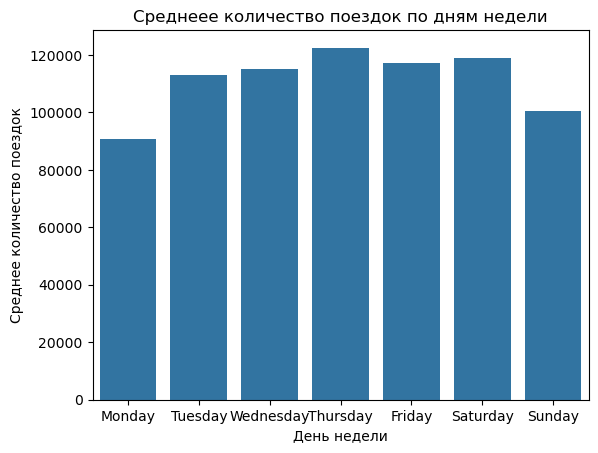

In [43]:
import seaborn as sns

first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели', xlabel='День недели', ylabel='Среднее количество поездок');

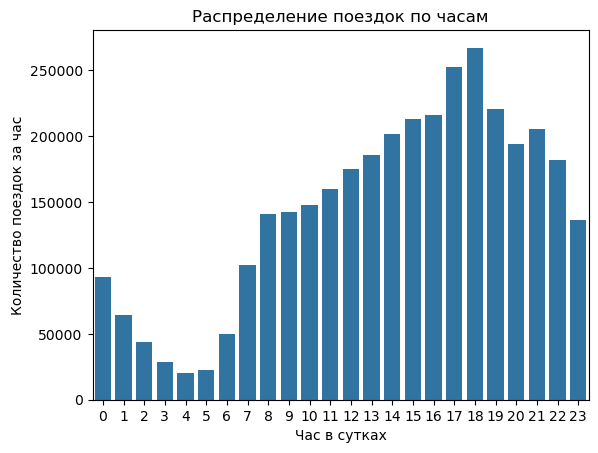

In [44]:
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(title='Распределение поездок по часам', xlabel='Час в сутках', ylabel='Количество поездок за час');

Минимальное количество поездок в среднем люди совершали в понедельник, максимальное - в четверг. Количество поездок достигает своего минимума в ранние утренние часы с 4 до 5 часов и максимума -
к вечеру с 17 до 18 часов. Активность поездок явно зависит от дня недели и от часа, поэтому при дальнейшем изучении спроса на такси необходимо будет учитывать день недели и час для сравнения.

Посмотрим теперь среднее количество поездок по дню недели и часу.

In [46]:
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()
# сгруппировала по дате, дню недели и часу, чтобы посчитать среднее
day_hour

,date,day_of_week,hour,trips
0,2025-01-01,Wednesday,0,7328
1,2025-01-01,Wednesday,1,8455
2,2025-01-01,Wednesday,2,7241
3,2025-01-01,Wednesday,3,4910
4,2025-01-01,Wednesday,4,2913
...,...,...,...,...
739,2025-01-31,Friday,19,10166
740,2025-01-31,Friday,20,7281
741,2025-01-31,Friday,21,7183
742,2025-01-31,Friday,22,8548


In [47]:
day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()

day_hour = day_hour.reset_index()
day_hour

,day_of_week,hour,trips
0,Friday,0,2307.0
1,Friday,1,1153.0
2,Friday,2,634.2
3,Friday,3,444.6
4,Friday,4,445.8
...,...,...,...
163,Wednesday,19,7322.6
164,Wednesday,20,6933.4
165,Wednesday,21,7585.2
166,Wednesday,22,5972.0


In [48]:
day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]
day_hour

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,1851.25,1153.25,2442.8,1431.4,2307.0,5779.75,6792.75
1,959.50,478.50,2080.2,624.4,1153.0,4438.50,5390.75
2,555.50,257.75,1656.2,353.4,634.2,3068.50,3776.25
3,394.75,188.50,1149.0,259.8,444.6,1849.00,2365.50
4,458.50,277.25,806.0,328.8,445.8,978.25,1310.50
5,771.25,719.00,861.4,751.4,840.4,485.75,583.25
6,1738.25,1973.50,1849.4,1983.8,1801.8,827.25,879.50
7,3432.75,4516.50,4001.8,4268.2,3797.8,1254.00,1274.00
8,4566.50,6338.75,5475.4,5953.8,4860.2,2027.75,1915.00


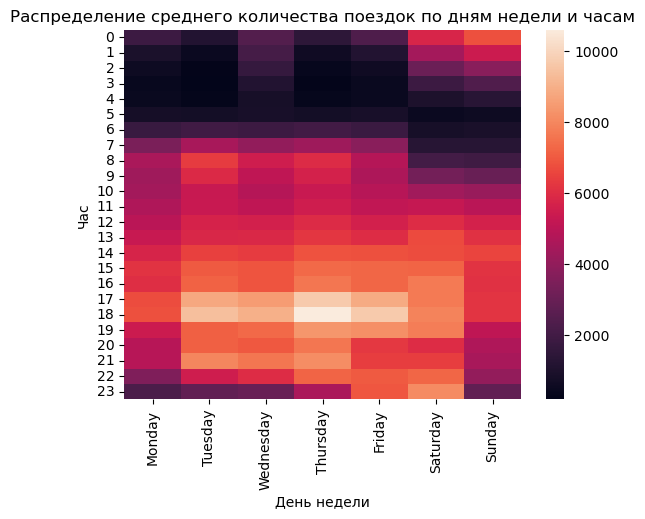

In [49]:
sns.heatmap(day_hour).set(
    title="Распределение среднего количества поездок по дням недели и часам", 
    xlabel="День недели", 
    ylabel="Час");

Со вторника по пятницу с 17 до 18 часов заметно активное повышение спроса на такси, пик активности - Четверг 18 часов. В будние дни с 0 до 5 часов, а также в выходные с 4 до 7 часов наблюдается спад спроса на такси.

Рассмотрим количество поездок на такси в конкретные даты января.

In [50]:
from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

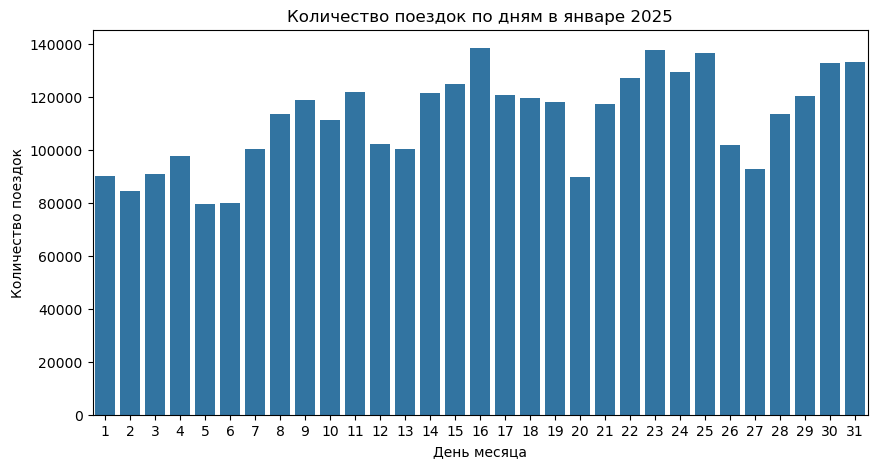

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в январе 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

Заметен паттерн: увеличение количества поездок в течение 5-6 дней, потом спад на 1-2 дня. Особенно низкие значения наблюдаются по понедельникам: 6, 13, 20, 27 числа.

Для временных признаков после минимальной очистки явных проблем, влияющих на текущий анализ, не обнаружено. Остальные признаки подробно не проверяю, поскольку они не используются при построении целевой переменной. Теперь изучим географические признаки, начнём с зоны посадки PULocationID.

In [52]:
start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_zone_borough

,trips,Borough,Zone
LocationID,,,
1,377,EWR,Newark Airport
2,6,Queens,Jamaica Bay
3,175,Bronx,Allerton/Pelham Gardens
4,7479,Manhattan,Alphabet City
5,3,Staten Island,Arden Heights
...,...,...,...
260,1476,Queens,Woodside
261,16650,Manhattan,World Trade Center
262,49594,Manhattan,Yorkville East


In [53]:
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough

,trips
Borough,
Staten Island,253
EWR,377
Bronx,14724
Brooklyn,66044
Queens,294930
Manhattan,3088004


3 миллиона поездок начинаются на Манхэттене и 250 - на Стейтен Айленде. Такая статистика ожидаема, так как я рассматриваю данные жёлтых такси. Жёлтые такси концентрируются в большом количестве именно на Манхэттене,  а вот в других районах они встречаются редко, там привычнее зелёные и другие виды такси.

In [54]:
start_zone = start_zone_borough.groupby(start_zone_borough["Zone"])["trips"].sum().sort_values()
start_zone = start_zone.to_frame()
start_zone

,trips
Zone,
Eltingville/Annadale/Prince's Bay,1
Freshkills Park,1
Rikers Island,1
Port Richmond,2
Oakwood,2
...,...
Times Sq/Theatre District,125804
JFK Airport,146123
Upper East Side North,155513


In [55]:
end_zone_borough = df.groupby(df["DOLocationID"]).size().rename("trips")
end_zone_borough = end_zone_borough.to_frame()
end_zone_borough = end_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
end_zone_borough = end_zone_borough.set_index("LocationID")

end_borough = end_zone_borough.groupby(end_zone_borough["Borough"])["trips"].sum().sort_values()
end_borough = end_borough.to_frame()
end_borough

,trips
Borough,
Staten Island,701
EWR,6861
Unknown,7870
Bronx,22681
Brooklyn,140778
Queens,162575
Manhattan,3112190


Для зоны высадки DOLocationID ситуация аналогична, наблюдаем явную концентрацию поездок на Манхэттене. Также заметно увеличение высадок относительно посадок в каждом районе, кроме Куинса.

In [56]:
end_zone = end_zone_borough.groupby(end_zone_borough["Zone"])["trips"].sum().sort_values()
end_zone = end_zone.to_frame()
end_zone

,trips
Zone,
Governor's Island/Ellis Island/Liberty Island,1
Jamaica Bay,4
Arden Heights,8
Rossville/Woodrow,11
Charleston/Tottenville,13
...,...
Murray Hill,99888
Times Sq/Theatre District,107996
Midtown Center,131038


Визуализировать данные по зонам и районам нет смысла из-за неравномерного распределения количества поездок.

# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ

Для анализа необходимо количество посадок Yellow Taxi в каждой выбранной Taxi Zone за каждый час. Выбранные зоны - зоны, в которых находятся выбранные музыкальные площадки для анализа.

In [57]:
# LocationID выбранных зон
venue_zone_ids = [79, 161, 163, 186, 239]

data_pickup = (
    df[df["PULocationID"].isin(venue_zone_ids)]
    .groupby([
        df["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df["PULocationID"].rename("LocationID")
    ])
    .size().rename("pickups")
    .reset_index()
)
data_pickup

,date,hour,LocationID,pickups
0,2025-01-01,0,79,353
1,2025-01-01,0,161,274
2,2025-01-01,0,163,161
3,2025-01-01,0,186,155
4,2025-01-01,0,239,270
...,...,...,...,...
3710,2025-01-31,23,79,625
3711,2025-01-31,23,161,156
3712,2025-01-31,23,163,159
3713,2025-01-31,23,186,119


In [58]:
# В таблице должно быть 31 день x 24 часа x 5 зон = 3720 записей,
# сейчас в таблице 3715 записей, пропуск строки значит, что в этот день, в этот час, в этом районе
# не было ни одной поездки на такси. Найдём такие записи и запишем для них 0 в pickups

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-01-01", "2025-01-31", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-01-01,0,79,353
1,2025-01-01,0,161,274
2,2025-01-01,0,163,161
3,2025-01-01,0,186,155
4,2025-01-01,0,239,270
...,...,...,...,...
3715,2025-01-31,23,79,625
3716,2025-01-31,23,161,156
3717,2025-01-31,23,163,159
3718,2025-01-31,23,186,119


# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

In [61]:
from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_01.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)